In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
products = pd.read_excel('data/products.xlsx')

In [56]:
products.head(1)

,product_id,level1,level2,name
0,1,Гигиена,Бритье,Кассеты для бритья Gillette Fusion ProGlide Po...


In [ ]:
orders = pd.read_excel('data/orders.xlsx')

In [57]:
orders.head(1)

,order_id,accepted_at,product_id,quantity,regular_price,price,cost_price
0,1517514900,2022-01-13 16:48:19,17122,1,169,169,74


In [58]:
merged_df = products.merge(orders, on='product_id')

In [59]:
merged_df

,product_id,level1,level2,name,order_id,accepted_at,quantity,regular_price,price,cost_price
0,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517497108,2022-01-13 17:49:12,6,18,18,14
1,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517494748,2022-01-13 20:12:01,2,18,18,14
2,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517368853,2022-01-13 09:34:18,1,18,18,14
3,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517676281,2022-01-13 08:21:53,2,18,18,14
4,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517600286,2022-01-13 14:32:24,4,18,18,14
...,...,...,...,...,...,...,...,...,...,...
3013,109637,Замороженная продукция,Замороженные полуфабрикаты,Пицца La Trattoria,1517469469,2022-01-13 15:34:08,1,229,179,89
3014,109637,Замороженная продукция,Замороженные полуфабрикаты,Пицца La Trattoria,1517528637,2022-01-13 16:31:16,1,229,179,89
3015,109637,Замороженная продукция,Замороженные полуфабрикаты,Пицца La Trattoria,1517696521,2022-01-13 10:55:53,1,229,179,89
3016,111797,Мясная гастрономия,Колбасы,Колбаса вареная Самокат,1517565373,2022-01-13 12:11:46,1,175,175,97


**Самая ходовая товарная группа**

In [60]:
df = merged_df.groupby('level1').agg({'quantity': 'sum'}).reset_index().sort_values('quantity', ascending=False)
df.head(5)

,level1,quantity
1,Безалкогольные напитки,534
11,Молочная продукция,483
19,Свежие овощи,262
10,Кулинария,250
0,Бакалея,239


[Text(0.5, 0, 'Название категории'),
 Text(0, 0.5, 'Количество проданного товара')]

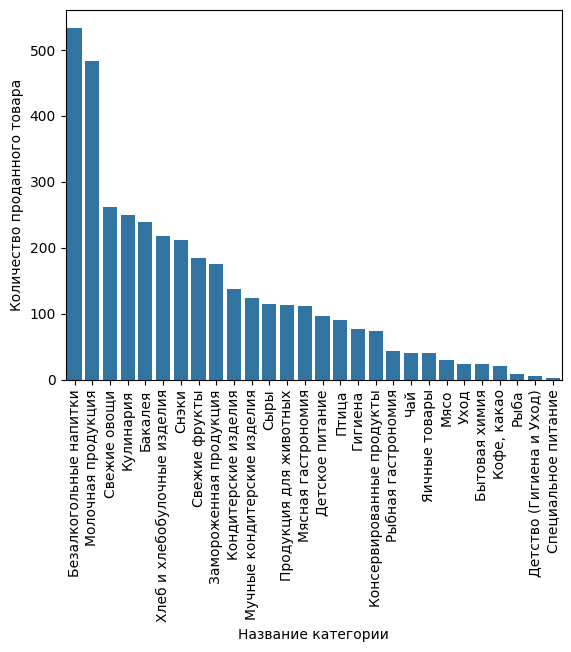

In [61]:
plot = sns.barplot(x=df['level1'], y=df['quantity'])

# Изменяем ориентацию подписей к осям
# https://stackoverflow.com/questions/26540035/rotate-label-text-in-seaborn-factorplot
plt.setp(plot.get_xticklabels(), rotation=90)

# Изменяем название осей
# https://stackoverflow.com/questions/31632637/label-axes-on-seaborn-barplot
plot.set(xlabel='Название категории', ylabel='Количество проданного товара')

**Распределение продаж по подкатегориям**

In [62]:
df = merged_df.groupby(['level1', 'level2']).agg({'quantity': 'sum'}).reset_index().sort_values('quantity', ascending=False)
df.head(5)

,level1,level2,quantity
13,Безалкогольные напитки,Напитки,252
54,Кулинария,Готовые блюда,248
95,Хлеб и хлебобулочные изделия,Хлеб и хлебобулочные изделия,218
86,Снэки,Снэки соленые,180
12,Безалкогольные напитки,Воды питьевые,162


**Найти средний чек в заданную дату**

In [63]:
orders[orders['accepted_at'].dt.strftime('%Y-%m-%d') == '2022-01-13'].groupby('order_id').apply(lambda x: (x['price'] * x['quantity']).sum(), include_groups=False).mean()

915.6378676470588

**Доля промо в заданной категории**

In [64]:
df = merged_df[merged_df['level1'] == 'Сыры'].copy()
df['is_promo'] = (df['regular_price'] > df['price'])
df.head(5)

,product_id,level1,level2,name,order_id,accepted_at,quantity,regular_price,price,cost_price,is_promo
116,1105,Сыры,Мягкие сыры,Сыр Моцарелла мини Самокат,1517510145,2022-01-13 19:22:00,2,129,129,73,False
117,1105,Сыры,Мягкие сыры,Сыр Моцарелла мини Самокат,1517609703,2022-01-13 08:46:56,1,116,116,73,False
118,1105,Сыры,Мягкие сыры,Сыр Моцарелла мини Самокат,1517675616,2022-01-13 18:23:57,1,129,129,73,False
119,1105,Сыры,Мягкие сыры,Сыр Моцарелла мини Самокат,1517521855,2022-01-13 19:57:03,1,129,129,73,False
265,2134,Сыры,Твердые сычужные сыры,Сыр сливочный Брест-Литовск,1517668073,2022-01-13 22:43:39,1,199,159,110,True


In [65]:
df[df['is_promo'] == True]['quantity'].sum() / df['quantity'].sum()

0.30701754385964913

In [66]:
m = {
    True: 'Промо',
    False: 'Не промо'
}

df = df.groupby('is_promo')['quantity'].sum().reset_index()
df['is_promo'] = df['is_promo'].map(m)

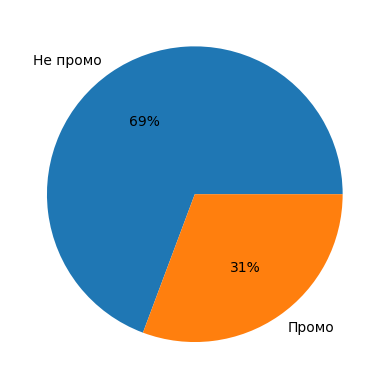

In [67]:
plt.pie(df['quantity'], labels=df['is_promo'], autopct='%.0f%%');

**Посчитать маржу по категориям**

In [68]:
def calc_margin(x):
    d = {}
    d['margin_rub'] = sum((x['price'] - x['cost_price'])*x['quantity'])
    d['margin_perc'] = d['margin_rub'] / sum(x['price']*x['quantity']) * 100
    return pd.Series(d, index=['margin_rub', 'margin_perc'])

In [69]:
merged_df.head()

,product_id,level1,level2,name,order_id,accepted_at,quantity,regular_price,price,cost_price
0,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517497108,2022-01-13 17:49:12,6,18,18,14
1,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517494748,2022-01-13 20:12:01,2,18,18,14
2,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517368853,2022-01-13 09:34:18,1,18,18,14
3,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517676281,2022-01-13 08:21:53,2,18,18,14
4,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517600286,2022-01-13 14:32:24,4,18,18,14


In [70]:
df = merged_df.groupby('level1').apply(calc_margin, include_groups=False).reset_index()
df

,level1,margin_rub,margin_perc
0,Бакалея,8177.0,37.567766
1,Безалкогольные напитки,20373.0,44.186349
2,Бытовая химия,1441.0,26.305221
3,Гигиена,2971.0,29.547489
4,Детское питание,1817.0,35.690434
5,Детство (Гигиена и Уход),517.0,29.901677
6,Замороженная продукция,13099.0,47.264920
7,Кондитерские изделия,5918.0,42.447282
8,Консервированные продукты,4154.0,41.124641
9,"Кофе, какао",5059.0,51.828706


[Text(0.5, 0, 'Маржа (руб)'), Text(0, 0.5, 'Категория товара')]

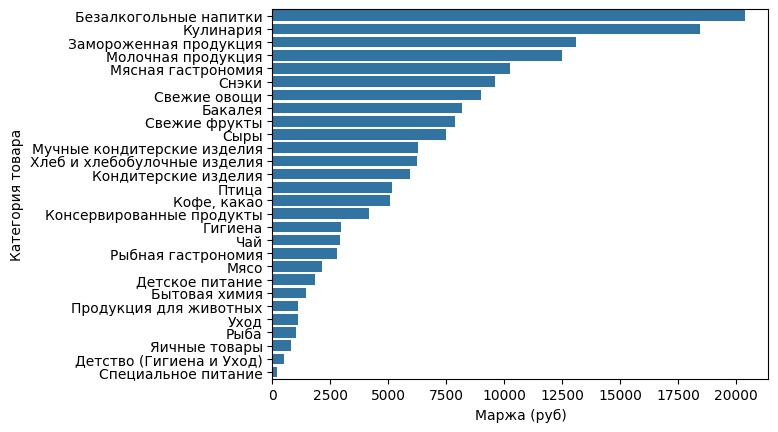

In [71]:
df_plot = df.sort_values('margin_rub', ascending=False)

plot = sns.barplot(data=df_plot, y='level1', x='margin_rub', orient='h')
plot.set(xlabel='Маржа (руб)', ylabel='Категория товара')

[Text(0.5, 0, 'Маржа (%)'), Text(0, 0.5, 'Категория товара')]

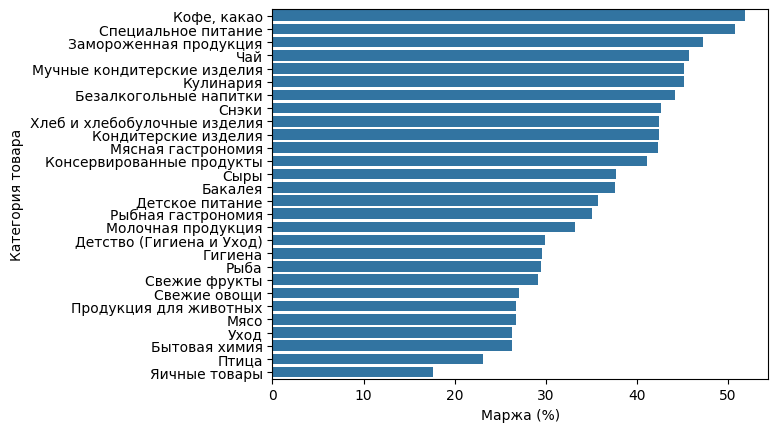

In [72]:
df_plot = df.sort_values('margin_perc', ascending=False)

plot = sns.barplot(data=df_plot, y='level1', x='margin_perc', orient='h')
plot.set(xlabel='Маржа (%)', ylabel='Категория товара')

**ABC анализ**

In [73]:
merged_df.head()

,product_id,level1,level2,name,order_id,accepted_at,quantity,regular_price,price,cost_price
0,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517497108,2022-01-13 17:49:12,6,18,18,14
1,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517494748,2022-01-13 20:12:01,2,18,18,14
2,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517368853,2022-01-13 09:34:18,1,18,18,14
3,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517676281,2022-01-13 08:21:53,2,18,18,14
4,23,Бакалея,Сухие блюда быстрого приготовления,Вермишель Роллтон,1517600286,2022-01-13 14:32:24,4,18,18,14


In [74]:
merged_df.groupby('level2').agg({'price': 'sum', 'quantity': 'sum'}).reset_index()

,level2,price,quantity
0,"Бананы, косточковые и прочие плоды",8929,76
1,Бараночные и сухарные изделия,460,8
2,Бритье,731,3
3,Бумажная продукция,4134,42
4,Влажные салфетки,255,2
...,...,...,...
95,Чайные напитки,1349,7
96,Черный чай,3789,26
97,Шоколад,3452,29
98,Шоколадные конфеты в коробках,447,3


In [75]:
df = merged_df.groupby('level2').apply(lambda x: pd.Series({
        'price': (x['price'] * x['quantity']).sum(),
        'quantity': x['quantity'].sum()
    }), include_groups=False).reset_index()

df = df.sort_values('price', ascending=False)
df['price_contribution'] = df['price'] / sum(df['price'])
df['price_cumsum'] = df['price_contribution'].cumsum()

def set_abc(x):
    if x < 0.8: 
        return 'A'
    elif x < 0.95:
        return 'B'
    else:
        return 'C'
    
df['ABC_price'] = df['price_cumsum'].apply(set_abc)

df = df.sort_values('quantity', ascending=False)
df['quantity_contribution'] = df['quantity'] / sum(df['quantity'])
df['quantity_cumsum'] = df['quantity_contribution'].cumsum()
df['ABC_quantity'] = df['quantity_cumsum'].apply(set_abc) 

df['ABC_join'] = df.filter(like='ABC').apply(' '.join, axis=1)
df

,level2,price,quantity,price_contribution,price_cumsum,ABC_price,quantity_contribution,quantity_cumsum,ABC_quantity,ABC_join
51,Напитки,24123,252,0.053990,0.144312,A,0.067524,0.067524,A,A A
10,Готовые блюда,40356,248,0.090322,0.090322,A,0.066452,0.133976,A,A A
92,Хлеб и хлебобулочные изделия,14724,218,0.032954,0.445747,A,0.058414,0.192390,A,A A
72,Снэки соленые,17293,180,0.038704,0.274058,A,0.048232,0.240622,A,A A
6,Воды питьевые,9141,162,0.020459,0.588058,A,0.043408,0.284030,A,A A
...,...,...,...,...,...,...,...,...,...,...
14,Диетическое питание,410,2,0.000918,0.993635,C,0.000536,0.998392,C,C C
81,Средства по уходу за волосами,665,2,0.001488,0.979528,C,0.000536,0.998928,C,C C
55,Освежители воздуха,568,2,0.001271,0.985027,C,0.000536,0.999464,C,C C
77,Средства для сантехники,239,1,0.000535,0.998398,C,0.000268,0.999732,C,C C


In [76]:
df.filter(like='ABC').apply(' '.join, axis=1)

51    A A A A
10    A A A A
92    A A A A
72    A A A A
6     A A A A
       ...   
14    C C C C
81    C C C C
55    C C C C
77    C C C C
71    C C C C
Length: 100, dtype: object